<a href="https://colab.research.google.com/github/Ashishnayak814/google_AIML/blob/main/Lab6-Cats-v-Dogs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Training with a Larger Dataset - Cats and Dogs

In the previous lab you trained a classifier with a horses-v-humans dataset. You saw that despite getting great training results, when you tried to do classification with real images, there were many errors, due primarily to overfitting -- where the network  does very well with data that it has previously seen, but poorly with data it hasn't!

In this lab you'll look at a real, and very large dataset, and see the impact this has to avoid overfitting.

In [1]:
import os
import zipfile
import random
import tensorflow as tf
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from shutil import copyfile

In [11]:
!wget --no-check-certificate \
    "https://storage.googleapis.com/tensorflow-1-public/course2/cats_and_dogs_filtered.zip" \
    -O "/tmp/cats-and-dogs.zip"

import zipfile
import os

local_zip = '/tmp/cats-and-dogs.zip'

if os.path.exists(local_zip) and os.path.getsize(local_zip) > 0:
    zip_ref = zipfile.ZipFile(local_zip, 'r')
    zip_ref.extractall('/tmp')
    zip_ref.close()
    print("Successfully extracted the dataset.")
else:
    print("Error: The zip file was not downloaded correctly.")

--2026-06-24 04:16:13--  https://storage.googleapis.com/tensorflow-1-public/course2/cats_and_dogs_filtered.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 108.177.127.207, 172.217.218.207, 142.251.31.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|108.177.127.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 68606236 (65M) [application/zip]
Saving to: ‘/tmp/cats-and-dogs.zip’

/tmp/cats-and-dogs. 100%[===================>]  65.43M  27.0MB/s    in 2.4s    

2026-06-24 04:16:16 (27.0 MB/s) - ‘/tmp/cats-and-dogs.zip’ saved [68606236/68606236]

Successfully extracted the dataset.


In [13]:
import os

# The dataset extracts to /tmp/cats_and_dogs_filtered
# Let's point to the correct subdirectories
print(len(os.listdir('/tmp/cats_and_dogs_filtered/train/cats/')))
print(len(os.listdir('/tmp/cats_and_dogs_filtered/train/dogs/')))

# Expected Output for this specific filtered dataset:
# 1000
# 1000

1000
1000


In [14]:
try:
    os.mkdir('/tmp/cats-v-dogs')
    os.mkdir('/tmp/cats-v-dogs/training')
    os.mkdir('/tmp/cats-v-dogs/testing')
    os.mkdir('/tmp/cats-v-dogs/training/cats')
    os.mkdir('/tmp/cats-v-dogs/training/dogs')
    os.mkdir('/tmp/cats-v-dogs/testing/cats')
    os.mkdir('/tmp/cats-v-dogs/testing/dogs')
except OSError:
    pass

In [15]:
def split_data(SOURCE, TRAINING, TESTING, SPLIT_SIZE):
    files = []
    for filename in os.listdir(SOURCE):
        file = SOURCE + filename
        if os.path.getsize(file) > 0:
            files.append(filename)
        else:
            print(filename + " is zero length, so ignoring.")

    training_length = int(len(files) * SPLIT_SIZE)
    testing_length = int(len(files) - training_length)
    shuffled_set = random.sample(files, len(files))
    training_set = shuffled_set[0:training_length]
    testing_set = shuffled_set[-testing_length:]

    for filename in training_set:
        this_file = SOURCE + filename
        destination = TRAINING + filename
        copyfile(this_file, destination)

    for filename in testing_set:
        this_file = SOURCE + filename
        destination = TESTING + filename
        copyfile(this_file, destination)

# Updated paths for the filtered dataset
CAT_SOURCE_DIR = "/tmp/cats_and_dogs_filtered/train/cats/"
TRAINING_CATS_DIR = "/tmp/cats-v-dogs/training/cats/"
TESTING_CATS_DIR = "/tmp/cats-v-dogs/testing/cats/"
DOG_SOURCE_DIR = "/tmp/cats_and_dogs_filtered/train/dogs/"
TRAINING_DOGS_DIR = "/tmp/cats-v-dogs/training/dogs/"
TESTING_DOGS_DIR = "/tmp/cats-v-dogs/testing/dogs/"

split_size = .9
split_data(CAT_SOURCE_DIR, TRAINING_CATS_DIR, TESTING_CATS_DIR, split_size)
split_data(DOG_SOURCE_DIR, TRAINING_DOGS_DIR, TESTING_DOGS_DIR, split_size)

In [16]:
print(len(os.listdir('/tmp/cats-v-dogs/training/cats/')))
print(len(os.listdir('/tmp/cats-v-dogs/training/dogs/')))
print(len(os.listdir('/tmp/cats-v-dogs/testing/cats/')))
print(len(os.listdir('/tmp/cats-v-dogs/testing/dogs/')))

# Expected output:
# 11250
# 11250
# 1250
# 1250

900
900
100
100


In [18]:
model = tf.keras.models.Sequential([
    # Using Input layer instead of input_shape in Conv2D
    tf.keras.layers.Input(shape=(150, 150, 3)),
    tf.keras.layers.Conv2D(16, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Updated lr to learning_rate
model.compile(optimizer=RMSprop(learning_rate=0.001), loss='binary_crossentropy', metrics=['acc'])

In [19]:

TRAINING_DIR = "/tmp/cats-v-dogs/training/"
train_datagen = ImageDataGenerator(rescale=1.0/255.)
train_generator = train_datagen.flow_from_directory(TRAINING_DIR,
                                                    batch_size=250,
                                                    class_mode='binary',
                                                    target_size=(150, 150))

VALIDATION_DIR = "/tmp/cats-v-dogs/testing/"
validation_datagen = ImageDataGenerator(rescale=1.0/255.)
validation_generator = validation_datagen.flow_from_directory(VALIDATION_DIR,
                                                              batch_size=250,
                                                              class_mode='binary',
                                                              target_size=(150, 150))

# Expected Output:
# Found 22498 images belonging to 2 classes.
# Found 2500 images belonging to 2 classes.

Found 1800 images belonging to 2 classes.
Found 200 images belonging to 2 classes.


In [20]:
# Note that this may take some time.
history = model.fit(train_generator, epochs=15, steps_per_epoch=90,
                    validation_data=validation_generator, validation_steps=6)

Epoch 1/15
 8/90 ━━━━━━━━━━━━━━━━━━━━ 52s 640ms/step - acc: 0.5198 - loss: 1.0089

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


90/90 ━━━━━━━━━━━━━━━━━━━━ 16s 79ms/step - acc: 0.5183 - loss: 0.9601 - val_acc: 0.5000 - val_loss: 0.6895
Epoch 2/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - acc: 0.5172 - loss: 0.6929 - val_acc: 0.6000 - val_loss: 0.6873
Epoch 3/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - acc: 0.5572 - loss: 0.6857 - val_acc: 0.5000 - val_loss: 0.6917
Epoch 4/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - acc: 0.5339 - loss: 0.6910 - val_acc: 0.5150 - val_loss: 0.6802
Epoch 5/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - acc: 0.5278 - loss: 0.6844 - val_acc: 0.5100 - val_loss: 0.6786
Epoch 6/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - acc: 0.5561 - loss: 0.6760 - val_acc: 0.6300 - val_loss: 0.6664
Epoch 7/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - acc: 0.5844 - loss: 0.6761 - val_acc: 0.6500 - val_loss: 0.6655
Epoch 8/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - acc: 0.6078 - loss: 0.6603 - val_acc: 0.5850 - val_loss: 0.6707
Epoch 9/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - acc: 0.5983 - loss: 0

<Figure size 640x480 with 0 Axes>

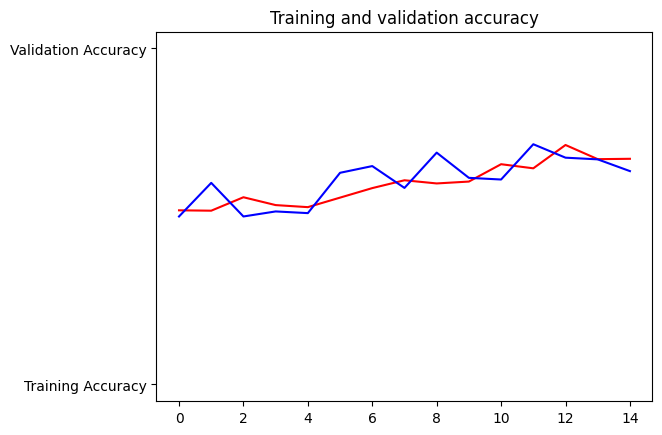

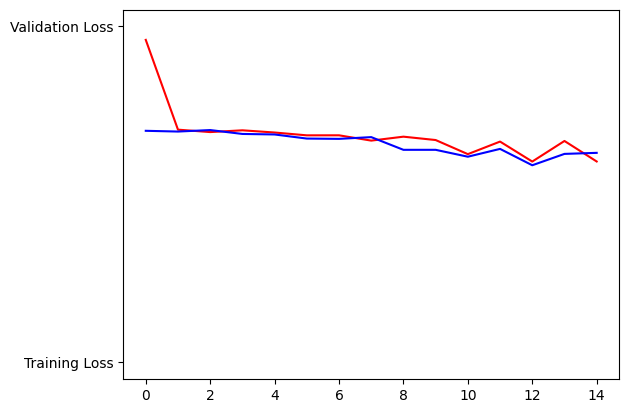

<Figure size 640x480 with 0 Axes>

In [21]:
%matplotlib inline

import matplotlib.image  as mpimg
import matplotlib.pyplot as plt

#-----------------------------------------------------------
# Retrieve a list of list results on training and test data
# sets for each training epoch
#-----------------------------------------------------------
acc=history.history['acc']
val_acc=history.history['val_acc']
loss=history.history['loss']
val_loss=history.history['val_loss']

epochs=range(len(acc)) # Get number of epochs

#------------------------------------------------
# Plot training and validation accuracy per epoch
#------------------------------------------------
plt.plot(epochs, acc, 'r', "Training Accuracy")
plt.plot(epochs, val_acc, 'b', "Validation Accuracy")
plt.title('Training and validation accuracy')
plt.figure()

#------------------------------------------------
# Plot training and validation loss per epoch
#------------------------------------------------
plt.plot(epochs, loss, 'r', "Training Loss")
plt.plot(epochs, val_loss, 'b', "Validation Loss")
plt.figure()


# Desired output. Charts with training and validation metrics. No crash :)

In [22]:
# Here's a codeblock just for fun. You should be able to upload an image here
# and have it classified without crashing
import numpy as np
from google.colab import files
from keras.preprocessing import image

uploaded = files.upload()

for fn in uploaded.keys():

  # predicting images
  path = '/content/' + fn
  img = image.load_img(path, target_size=(150, 150))
  x = image.img_to_array(img)
  x = np.expand_dims(x, axis=0)

  images = np.vstack([x])
  classes = model.predict(images, batch_size=10)
  print(classes[0])
  if classes[0]>0.5:
    print(fn + " is a dog")
  else:
    print(fn + " is a cat")

Saving images.jpg to images.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
[1.]
images.jpg is a dog
